# NASA TR 729 — Regime of Validity

This notebook characterizes the **regime of validity** of the solver using the low-speed axial fan from NACA Technical Report 729, operating at **60 RPS**. Rather than validating accuracy, the goal is to identify the combinations of **inlet axial velocity** and **rotor speed** that cause solver breakdown.

In [59]:
import sys
from pathlib import Path

PROJECT_ROOT = Path().resolve().parent
sys.path.insert(0, str(PROJECT_ROOT))

print("Project root:", PROJECT_ROOT)

import pandas as pd
import math
import numpy as np
from axialfans.fan_solver import MultistageFanSolver, State
import matplotlib.pyplot as plt

M = 200 # grid resolution

# -------------------------
# Gas Properties
# -------------------------
T0 = 288.15
P0 = 101325
rho0 = 1.229
R = 287.053
cp = 1005
gamma = 1.4

Project root: C:\Users\yokit\Documents\Sean\VSCode\axialfans


## Literature Data — NACA TR 729

Experimental data is reported in non-dimensional form. The three key parameters are:

- **RPS** — rotor speed (rev/s)
- **$\eta$** — total-to-total efficiency
- **$C_P$** — pressure coefficient (not heat capacity), defined as $C_P = \Delta P / (\rho \cdot n^2 \cdot D^2)$
- **$Q/nD^3$** — volumetric flow coefficient

These are converted to SI using the reference air density, annular geometry, and unit conversions below.

In [60]:
rps = 60
eta = 0.850
Cp = 1.85

# --- Constants ---
rho_ft = 0.076723964        # Reference density in slug/ft^3
conversion_factor = 47.88   # Pa / (lb/ft^2)
ft_to_m = 0.3048            # Conversion from feet to meters
r_plus_ft = 0.2667 / ft_to_m  # Outer radius in ft (from SI)
r_minus_ft = 0.18415 / ft_to_m # Inner radius in ft
D_ft = 1.75                 # Rotor diameter in ft

# Annular area in ft^2
A_ft2 = np.pi * (r_plus_ft**2 - r_minus_ft**2)

# Initial Axial Velocity (using their formulas)
vax0 = (0.45 * rps * D_ft**3) / A_ft2
vax0 *= ft_to_m

print(f"Initial axial velocity (vax0): {vax0:.2f} m/s")

# Absolute pressure rise (using their formulas)
delta_P_ideal = Cp * rho_ft * (rps**2) * (D_ft**2) * conversion_factor
print(f"delta_P_ideal: {delta_P_ideal:.2f} Pa")

PR_ideal = delta_P_ideal / P0 + 1 
print("Pressure Ratio (PR_ideal): ", PR_ideal)

omega_rotor = rps * 2 * math.pi
print(f"Omega: {omega_rotor:.2f} rad/s")

Initial axial velocity (vax0): 35.04 m/s
delta_P_ideal: 74926.51 Pa
Pressure Ratio (PR_ideal):  1.739467155165969
Omega: 376.99 rad/s


## Geometry and Slip Factor

Blade angles are measured relative to the axial direction and converted from NACA TR 729's convention (angles measured from the $r$-$\theta$ plane). The rotor twists from hub to tip in the standard sense; the stator twists in the opposite direction.

The slip factor is computed using the **modified Stodola model**, applied consistently to both rotor and stator:

$$\sigma = 1 - \frac{C}{Z}$$

where $C = 1.5408$ is calibrated from the Rotor 37 deterministic case and $Z$ is blade count.

In [61]:
def sigma_model(Z):
    return 1 - 1.5408 / Z

sigma_rotor, sigma_stator = sigma_model(24), sigma_model(37)
print(f"Sigma Rotor: {sigma_rotor:.4f}, Sigma Stator: {sigma_stator:.4f}")

beta_hub_rotor = 65 # relative to axial direction, converted from their angles measured from the r-theta plane.
beta_hub_stator = 20

beta_tip_rotor = 71 # twisted
beta_tip_stator = 11 # twisted the other direction

# Create the rows
rotor_row = np.linspace(beta_hub_rotor, beta_tip_rotor, M)
stator_row = np.linspace(beta_hub_stator, beta_tip_stator, M)

# Combine into a matrix (M entries per row, 2 rows total)
beta_matrix = np.array([rotor_row, stator_row])

# Effective tip and hub radii for both rows
rp = 0.2667                # m
rm = 0.18415               # m

Sigma Rotor: 0.9358, Sigma Stator: 0.9584


## Deterministic Solve — Single Operating Point

The solver is configured as a two-row stage (rotor + stator) and run at the NACA TR 729 design point. A pressure ratio below 1.0 indicates solver breakdown — the inviscid compressible model cannot sustain physically consistent results at low speed.

In [62]:
solver = MultistageFanSolver(
    N=2,
    M=M,
    direction=[1, -1],
    sigma=[sigma_rotor, sigma_stator],
    omega=[omega_rotor, 0],
    beta=beta_matrix,
    rp=rp,
    rm=rm,
    eta=eta,
    R=R,
    cp=cp,
    gamma=gamma
)

inlet_state = State(0, M, rm, rp, T0, P0, vax0, rho0, 0)
solver.solve(inlet_state)

PR_calculated = solver.performance()['PR']

print("Pressure Ratio (PR_calculated): ", PR_calculated)
print("Pressure Ratio (PR_ideal): ", PR_ideal)
print(f"Error = {(PR_calculated - PR_ideal) / PR_ideal * 100:.2f} %")

Pressure Ratio (PR_calculated):  0.9978004088039747
Pressure Ratio (PR_ideal):  1.739467155165969
Error = -42.64 %


## Reynolds Number Analysis

At 60 RPS, the fan operates in a viscosity-dominated regime where the inviscid assumption breaks down. Reynolds number is computed across a range of $\omega$ to identify where viscous effects become non-negligible. Rotor 37 at 1800 rad/s is included as a reference point — the contrast in Re explains why the inviscid solver works there but not here.

=== REYNOLDS NUMBER ANALYSIS OF FAN 6 ===

Normal Speed
----------------------------------------
ω = 377.0 rad/s
U = 69.4 m/s
Re = 4.07e+05

Fast Speed
----------------------------------------
ω = 1800.0 rad/s
U = 331.5 m/s
Re = 1.94e+06


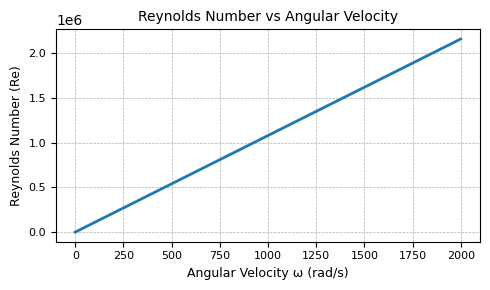

In [63]:
import numpy as np

print("=== REYNOLDS NUMBER ANALYSIS OF FAN 6 ===\n")

# Physical constants
mu = 1.73e-5  # Pa·s, air dynamic viscosity
chord = rp - rm  # m, blade chord length

print("Normal Speed")
print("-" * 40)
omega_729 = 60 * 2 * np.pi  # rad/s (60 rps)
U_729 = omega_729 * rm  # m/s, tangential velocity (conservative)
Re_729 = rho0 * U_729 * chord / mu
print(f"ω = {omega_729:.1f} rad/s")
print(f"U = {U_729:.1f} m/s")
print(f"Re = {Re_729:.2e}")

print("\nFast Speed")
print("-" * 40)
omega_R37 = 1800  # rad/s
U_R37 = omega_R37 * rm  # m/s
Re_R37 = rho0 * U_R37 * chord / mu
print(f"ω = {omega_R37:.1f} rad/s")
print(f"U = {U_R37:.1f} m/s")
print(f"Re = {Re_R37:.2e}")

# Range of angular velocities
omega_values = np.linspace(0, 2000, 100)  # rad/s

# Compute Reynolds number
U_values = omega_values * rm
Re_values = rho0 * U_values * chord / mu

# Create a smaller, cleaner figure (single plot only)
plt.figure(figsize=(5, 3))
plt.plot(omega_values, Re_values, linewidth=2)

plt.xlabel("Angular Velocity ω (rad/s)", fontsize=9)
plt.ylabel("Reynolds Number (Re)", fontsize=9)
plt.title("Reynolds Number vs Angular Velocity", fontsize=10)

plt.grid(True, linestyle="--", linewidth=0.5)
plt.tick_params(labelsize=8)
plt.tight_layout()

plt.show()

## Parametric Sweep — Regime Map

The solver is swept over a grid of inlet axial velocities ($v_{ax} \in [0, 200]$ m/s) and rotor speeds ($\omega \in [0, 2000]$ rad/s) at 30 points each (900 total). All other parameters are held at the NACA TR 729 design values. Solver breakdown is flagged where PR $< 1$.

In [64]:
from tqdm import tqdm
import os

vax_values = np.linspace(1, 200, 30)   # m/s
omega_values = np.linspace(1, 2000, 30) # rad/s
PR_grid = np.zeros((len(omega_values), len(vax_values)))

data_path = '../data/naca729_PR_grid.npy'

if os.path.exists(data_path):
    PR_grid = np.load(data_path)
    print(f"Loaded PR grid from {data_path}")
else:
    PR_grid = np.zeros((len(omega_values), len(vax_values)))

    for i, omega in enumerate(tqdm(omega_values, desc="Sweeping omega")):
        for j, vax in enumerate(vax_values):
            try:
                s = MultistageFanSolver(
                    N=2, M=M,
                    direction=[1, -1],
                    sigma=[sigma_rotor, sigma_stator],
                    omega=[omega, 0],
                    beta=beta_matrix,
                    rp=rp, rm=rm,
                    eta=eta, R=R, cp=cp, gamma=gamma
                )
                inlet = State(0, M, rm, rp, T0, P0, vax, rho0, 0)
                s.solve(inlet)
                PR_grid[i, j] = s.performance()['PR']
            except Exception:
                PR_grid[i, j] = np.nan

    np.save(data_path, PR_grid)
    print(f"Sweep complete. Saved to {data_path}")

print(f"Valid points: {np.sum(PR_grid >= 1)} / {PR_grid.size}")

Loaded PR grid from ../data/naca729_PR_grid.npy
Valid points: 410 / 900


## Regime Map

Pressure ratio across the $(v_{ax}, \omega)$ sweep plotted as a filled contour (plasma colormap). The **PR = 1 isocline** marks the solver validity boundary — below it the inviscid model breaks down. The **red dashed line** at $\omega = 1000$ rad/s marks where Re $= 10^6$, below which viscous effects become non-negligible. Stars mark the NACA TR 729 design point (slow) and an equivalent geometry at Rotor 37 speeds (fast).

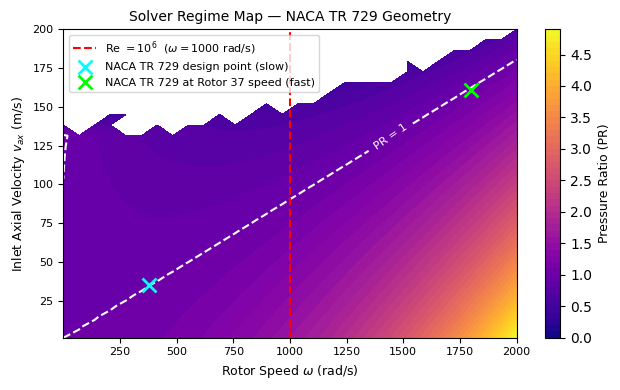

In [65]:
fig, ax = plt.subplots(figsize=(6.5, 4.0))

VAX, OMEGA = np.meshgrid(vax_values, omega_values)

cf = ax.contourf(OMEGA, VAX, PR_grid, levels=50, cmap='plasma')
cbar = fig.colorbar(cf, ax=ax)
cbar.set_label('Pressure Ratio (PR)', fontsize=9)

# PR = 1 isocline
cs = ax.contour(OMEGA, VAX, PR_grid, levels=[1.0], colors='white', linewidths=1.5, linestyles='--')
ax.clabel(cs, fmt='PR = 1', fontsize=8, inline=True, manual=[(1500, 120)])

# Re = 1e6 line at omega = 1000 rad/s
ax.axvline(x=1000, color='red', linewidth=1.5, linestyle='--', label=r'Re $= 10^6$  ($\omega = 1000$ rad/s)')

# Xs
ax.plot(60 * 2 * np.pi, vax0, 'x', color='cyan', markersize=10, markeredgewidth=2, zorder=5, label='NACA TR 729 design point (slow)')
ax.plot(1800, 161, 'x', color='lime', markersize=10, markeredgewidth=2, zorder=5, label='NACA TR 729 at Rotor 37 speed (fast)')

ax.set_xlabel('Rotor Speed $\\omega$ (rad/s)', fontsize=9)
ax.set_ylabel('Inlet Axial Velocity $v_{ax}$ (m/s)', fontsize=9)
ax.set_title('Solver Regime Map — NACA TR 729 Geometry', fontsize=10)
ax.legend(fontsize=8, loc='upper left')
ax.tick_params(labelsize=8)

plt.tight_layout()
plt.savefig('figures/regime_map.png', dpi=300, bbox_inches='tight')
plt.show()

## Analysis

The regime map reveals that solver validity is governed by the **flow coefficient** $\phi = v_{ax} / U$, where $U = \omega r$ is the local blade speed, rather than either quantity independently. This explains the diagonal character of the PR = 1 isocline: high inlet axial velocity is permissible provided rotor speed is correspondingly large, preserving a physically realizable velocity triangle at the blade.

At low $\omega$, blade speed is insufficient to impart meaningful work on the flow regardless of $v_{ax}$. At high $v_{ax}$ relative to $\omega$, the incidence angle exceeds the blade's geometric turning capacity — a condition physically associated with leading edge separation and stall, which the inviscid model cannot represent. In both cases the solver returns PR $< 1$, indicating breakdown rather than a physical result.

The Reynolds number boundary at $\omega = 1000$ rad/s (Re $= 10^6$) provides a complementary criterion: below this threshold, viscous forces are non-negligible relative to inertial forces and the inviscid assumption is physically unjustified independent of the velocity triangle geometry. The NACA TR 729 design point at 60 RPS ($\omega \approx 377$ rad/s) falls below both boundaries, explaining the solver's failure at this operating condition. An equivalent geometry accelerated to Rotor 37 speeds ($\omega = 1800$ rad/s) crosses both boundaries into the valid regime, consistent with the <3% error observed in the Rotor 37 and Rotor 67 validation cases.